# Tomography Scan Explorer

Load an HDF5 file produced by `tomography_scan.py` and explore: projection counts, beam position stability, beam current drift, and basic statistics.

In [6]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob, os

In [7]:
# Find and load the most recent scan HDF5
# Override: set h5_path = Path("path/to/scan_....h5") before running this cell

try:
    h5_path
except NameError:
    demo_dir = Path.cwd()
    files = sorted(glob.glob(str(demo_dir / "scan_*.h5")), key=os.path.getmtime, reverse=True)
    if not files:
        raise FileNotFoundError(
            f"No scan_*.h5 files found in {demo_dir}. "
            f"Run tomography_scan.py first, or set h5_path = Path(\"...\")."
        )
    h5_path = Path(files[0])

print(f"Loading: {h5_path}")

f = h5py.File(h5_path, "r")
ds = f["projections"]
data = ds[:]  # read all into memory

# Metadata
print("\n=== Scan Metadata ===")
for key in sorted(f.attrs):
    print(f"  {key}: {f.attrs[key]}")
print(f"  frames: {ds.shape[0]}")
print(f"  fields: {ds.dtype.names}")
print(f"  angle: {data['angle'][0]:.2f} .. {data['angle'][-1]:.2f} deg")
print(f"  counts: {data['counts'].min():.0f} .. {data['counts'].max():.0f}")

Loading: /home/ingvord/Projects/rx-controls-suite/RxEpics/python/demo/tomography/scan_20260512_001504.h5

=== Scan Metadata ===
  exposure_ms: 30.0
  motor_speed: 10.0
  num_projections: 360
  frames: 360
  fields: ('timestamp', 'proj_index', 'angle', 'counts', 'beam_current', 'beam_posx', 'beam_posy')
  angle: 0.00 .. 180.00 deg
  counts: 2815 .. 3150


### Projections: counts vs angle

Each point is one detector frame. Counts should be roughly constant (~3000 for 30ms exposure) with Poisson noise. A trend or step indicates beam drift or a real sample feature.

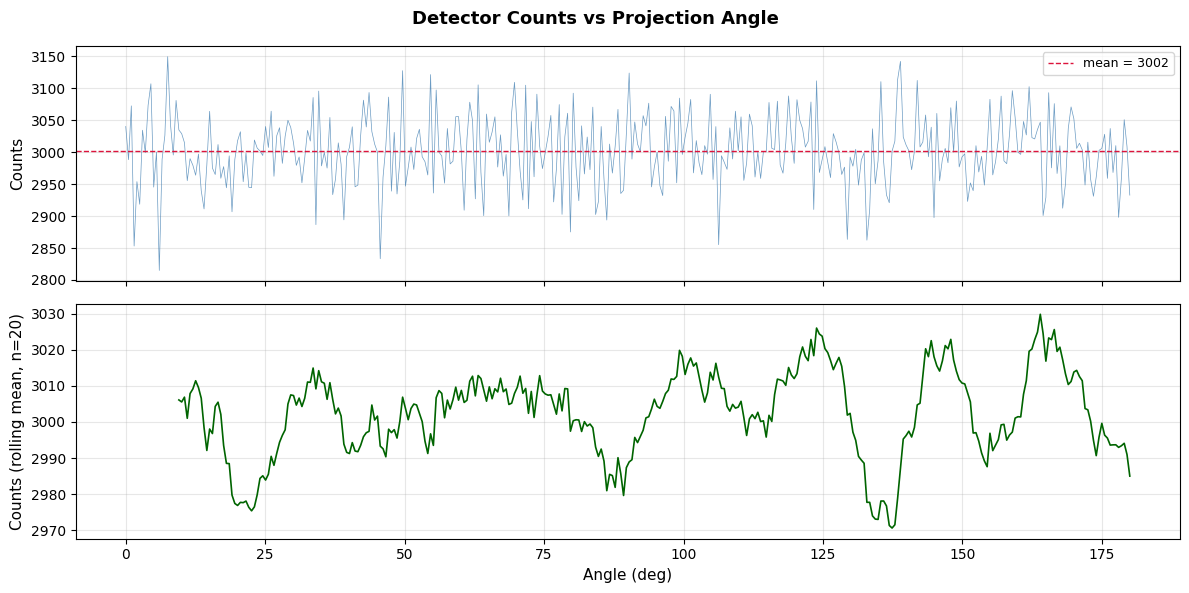

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(data["angle"], data["counts"], lw=0.5, color="steelblue", alpha=0.8)
ax1.axhline(np.mean(data["counts"]), color="crimson", ls="--", lw=1,
            label=f"mean = {np.mean(data["counts"]):.0f}")
ax1.set_ylabel("Counts", fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

window = min(20, len(data))
smooth = np.convolve(data["counts"], np.ones(window)/window, mode="valid")
ax2.plot(data["angle"][window-1:], smooth, lw=1.2, color="darkgreen")
ax2.set_xlabel("Angle (deg)", fontsize=11)
ax2.set_ylabel(f"Counts (rolling mean, n={window})", fontsize=11)
ax2.grid(True, alpha=0.3)

fig.suptitle("Detector Counts vs Projection Angle", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

### Beam position stability

Scatter plot of beam centroid X vs Y over the scan. A tight cluster means stable beam; drift or outliers flag a problem.

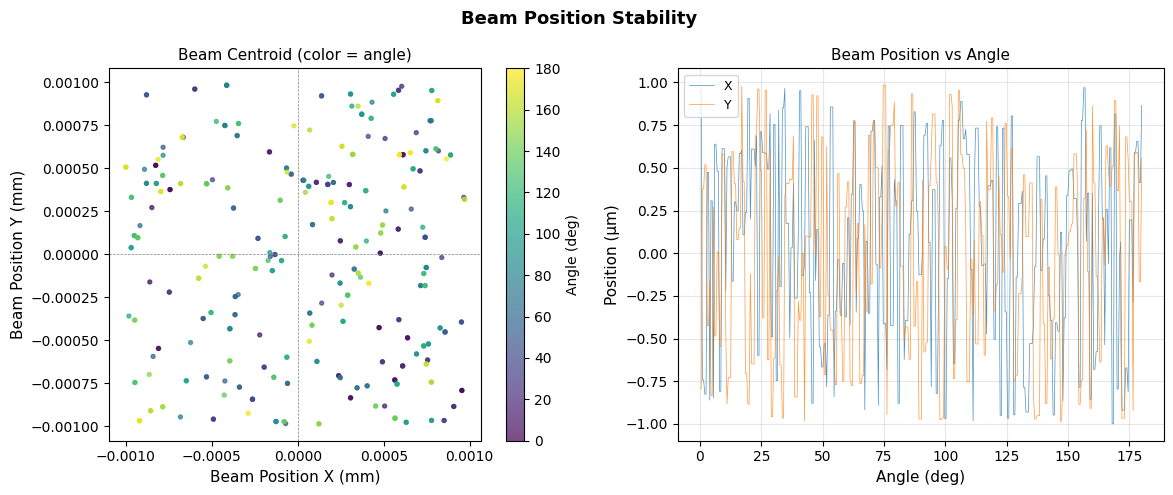

Beam X: mean=+0.068 μm, std=0.569 μm
Beam Y: mean=-0.023 μm, std=0.584 μm


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sc = ax1.scatter(data["beam_posx"], data["beam_posy"], c=data["angle"],
                 cmap="viridis", s=8, alpha=0.7)
ax1.axhline(0, color="gray", ls="--", lw=0.5)
ax1.axvline(0, color="gray", ls="--", lw=0.5)
ax1.set_xlabel("Beam Position X (mm)", fontsize=11)
ax1.set_ylabel("Beam Position Y (mm)", fontsize=11)
ax1.set_title("Beam Centroid (color = angle)", fontsize=11)
ax1.set_aspect("equal")
plt.colorbar(sc, ax=ax1, label="Angle (deg)")

ax2.plot(data["angle"], data["beam_posx"] * 1000, lw=0.5, label="X", alpha=0.8)
ax2.plot(data["angle"], data["beam_posy"] * 1000, lw=0.5, label="Y", alpha=0.8)
ax2.set_xlabel("Angle (deg)", fontsize=11)
ax2.set_ylabel("Position (μm)", fontsize=11)
ax2.set_title("Beam Position vs Angle", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig.suptitle("Beam Position Stability", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

print(f"Beam X: mean={data["beam_posx"].mean()*1000:+.3f} μm, std={data["beam_posx"].std()*1000:.3f} μm")
print(f"Beam Y: mean={data["beam_posy"].mean()*1000:+.3f} μm, std={data["beam_posy"].std()*1000:.3f} μm")

### Beam current and normalised count rate

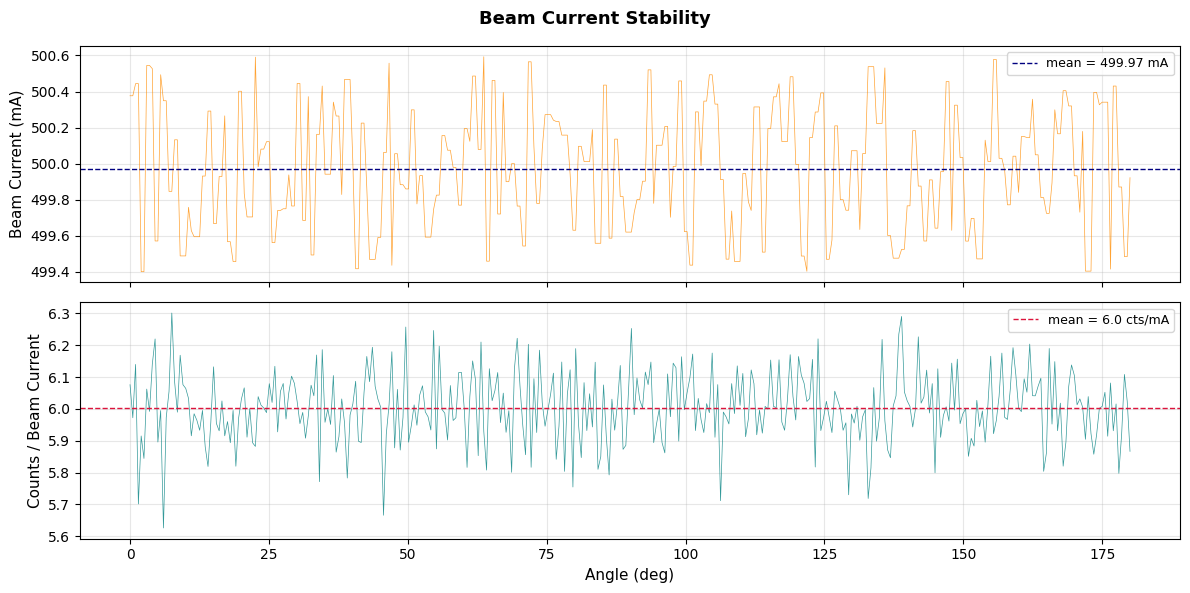

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(data["angle"], data["beam_current"], lw=0.5, color="darkorange", alpha=0.8)
ax1.axhline(np.mean(data["beam_current"]), color="navy", ls="--", lw=1,
            label=f"mean = {np.mean(data["beam_current"]):.2f} mA")
ax1.set_ylabel("Beam Current (mA)", fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

normalized = data["counts"] / data["beam_current"]
ax2.plot(data["angle"], normalized, lw=0.5, color="teal", alpha=0.8)
ax2.axhline(np.mean(normalized), color="crimson", ls="--", lw=1,
            label=f"mean = {np.mean(normalized):.1f} cts/mA")
ax2.set_xlabel("Angle (deg)", fontsize=11)
ax2.set_ylabel("Counts / Beam Current", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig.suptitle("Beam Current Stability", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

### Summary statistics

In [11]:
print("=== Tomography Scan Summary ===")
print(f"File: {h5_path}\n")

elapsed = data["timestamp"][-1] - data["timestamp"][0]
fps = len(data) / elapsed if elapsed > 0 else float("inf")
cts_per_ma = data["counts"].mean() / data["beam_current"].mean()

print(f"  Frames:          {len(data)}")
print(f"  Elapsed:         {elapsed:.1f} s")
print(f"  Frame rate:      {fps:.1f} fps")
print(f"  Angle range:     {data["angle"][0]:.2f} to {data["angle"][-1]:.2f} deg")
print()
print(f"  Counts:          mean={data["counts"].mean():.0f}  std={data["counts"].std():.0f}")
print(f"  Beam current:    mean={data["beam_current"].mean():.2f}  std={data["beam_current"].std():.3f} mA")
print(f"  Counts / mA:     {cts_per_ma:.1f}")
print()
print(f"  Beam pos X:      mean={data["beam_posx"].mean()*1000:+.3f}  std={data["beam_posx"].std()*1000:.3f} μm")
print(f"  Beam pos Y:      mean={data["beam_posy"].mean()*1000:+.3f}  std={data["beam_posy"].std()*1000:.3f} μm")
print(f"  Beam drift:      {np.sqrt(data["beam_posx"].std()**2 + data["beam_posy"].std()**2)*1e6:.1f} μm RMS")

f.close()

=== Tomography Scan Summary ===
File: /home/ingvord/Projects/rx-controls-suite/RxEpics/python/demo/tomography/scan_20260512_001504.h5

  Frames:          360
  Elapsed:         38.7 s
  Frame rate:      9.3 fps
  Angle range:     0.00 to 180.00 deg

  Counts:          mean=3002  std=56
  Beam current:    mean=499.97  std=0.335 mA
  Counts / mA:     6.0

  Beam pos X:      mean=+0.068  std=0.569 μm
  Beam pos Y:      mean=-0.023  std=0.584 μm
  Beam drift:      815.8 μm RMS
